In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [2]:
# make a moon shape dataset and ignore the labels 
X , _ = make_moons(
    n_samples = 200 , noise = 0.05 , random_state = 42
)

In [3]:
X.shape

(200, 2)

In [4]:
X[0]

array([-1.02069027,  0.10551754])

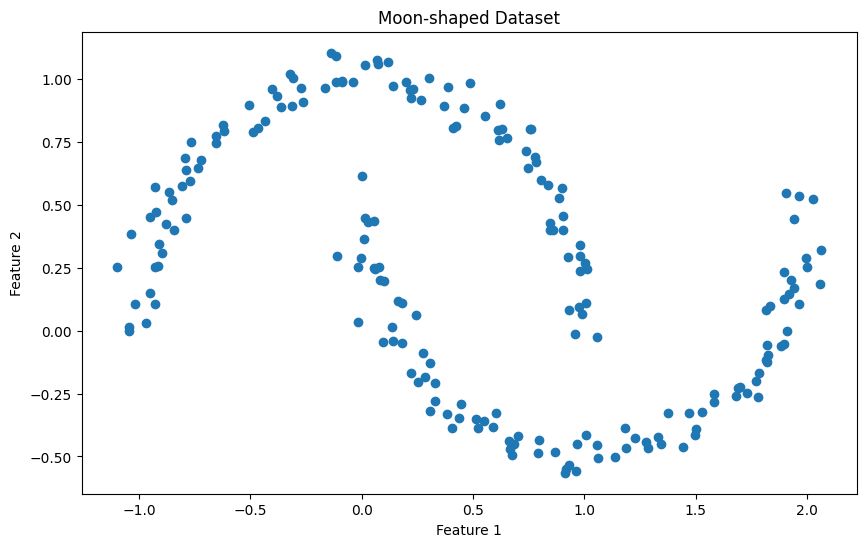

In [5]:
plt.figure(figsize = (10 , 6))
plt.scatter(x = X[ : , 0] , y = X[ : , 1])
plt.title('Moon-shaped Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

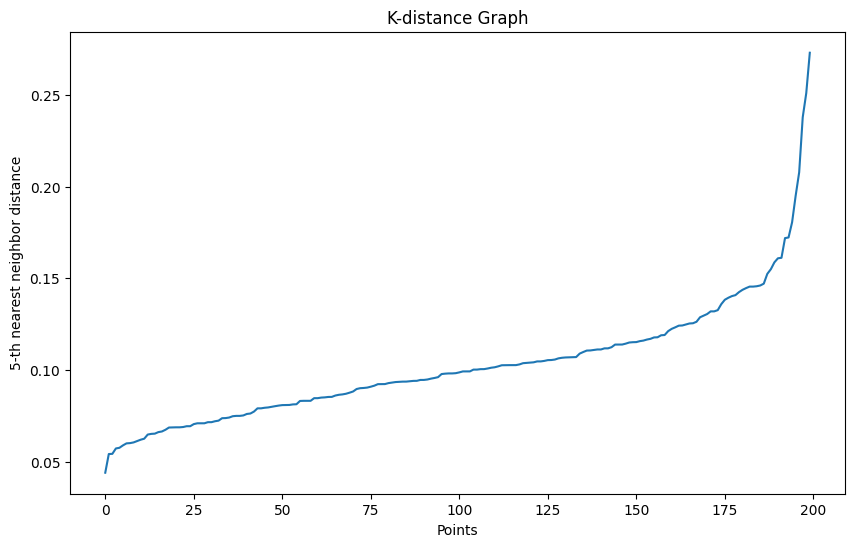

In [6]:
# Function to plot k-distance graph
def plot_k_distance_graph(X , k):
    neigh = NearestNeighbors(n_neighbors = k)
    neigh.fit(X)
    distances , _ = neigh.kneighbors(X)
    distances = np.sort(distances[ : , k - 1])
    plt.figure(figsize = (10 , 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(X, k = 5)

- Note: Here we can see a bend at 0.15 distance value, bending value. Bend value will be our epsilon for DBSCAN 

In [8]:
epsilon = 0.15
min_samples = 4 # 2 * D 
dbscan = DBSCAN(eps = epsilon , min_samples = min_samples)
clusters = dbscan.fit_predict(X)
clusters

array([ 0,  0,  0,  1,  1,  1,  0,  1,  1,  0,  0,  1,  1,  0,  1,  1,  0,
        1,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,
        1,  1,  1,  1,  1,  0,  0,  2,  0,  0,  1,  2,  0,  0,  1,  0,  1,
        1,  0,  1,  1,  0,  1,  0,  1,  0,  1,  0,  0,  0,  0,  1,  0,  1,
        0,  1,  0,  1,  1,  0,  1,  1,  0,  1, -1,  1,  0,  0,  0,  1,  1,
        0,  1,  0,  1,  0,  0,  1,  1,  0,  0,  1,  1,  0,  0,  1,  0,  0,
        1,  1,  1,  1,  0,  0,  1,  1,  1,  0,  2,  1,  0,  1,  0,  0,  1,
        0,  0,  1,  1,  1,  0,  0,  1,  1,  0,  0,  1,  0,  0,  1,  0,  1,
        0,  1,  0,  1,  1,  1,  1,  0,  0,  0,  0,  1,  0,  0,  1,  1,  0,
        0,  0,  0,  1,  1,  0,  0,  1,  1,  1,  1,  0,  0,  1,  0,  1,  0,
        0,  0,  0,  0,  1,  1,  1,  0,  1,  1,  0,  0,  1,  1,  1,  1,  0,
        1,  0,  0,  1,  2,  0,  1,  0,  1,  0,  0,  1,  1])

In [9]:
dbscan.labels_

array([ 0,  0,  0,  1,  1,  1,  0,  1,  1,  0,  0,  1,  1,  0,  1,  1,  0,
        1,  0,  0,  1,  0,  1,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0,
        1,  1,  1,  1,  1,  0,  0,  2,  0,  0,  1,  2,  0,  0,  1,  0,  1,
        1,  0,  1,  1,  0,  1,  0,  1,  0,  1,  0,  0,  0,  0,  1,  0,  1,
        0,  1,  0,  1,  1,  0,  1,  1,  0,  1, -1,  1,  0,  0,  0,  1,  1,
        0,  1,  0,  1,  0,  0,  1,  1,  0,  0,  1,  1,  0,  0,  1,  0,  0,
        1,  1,  1,  1,  0,  0,  1,  1,  1,  0,  2,  1,  0,  1,  0,  0,  1,
        0,  0,  1,  1,  1,  0,  0,  1,  1,  0,  0,  1,  0,  0,  1,  0,  1,
        0,  1,  0,  1,  1,  1,  1,  0,  0,  0,  0,  1,  0,  0,  1,  1,  0,
        0,  0,  0,  1,  1,  0,  0,  1,  1,  1,  1,  0,  0,  1,  0,  1,  0,
        0,  0,  0,  0,  1,  1,  1,  0,  1,  1,  0,  0,  1,  1,  1,  1,  0,
        1,  0,  0,  1,  2,  0,  1,  0,  1,  0,  0,  1,  1])

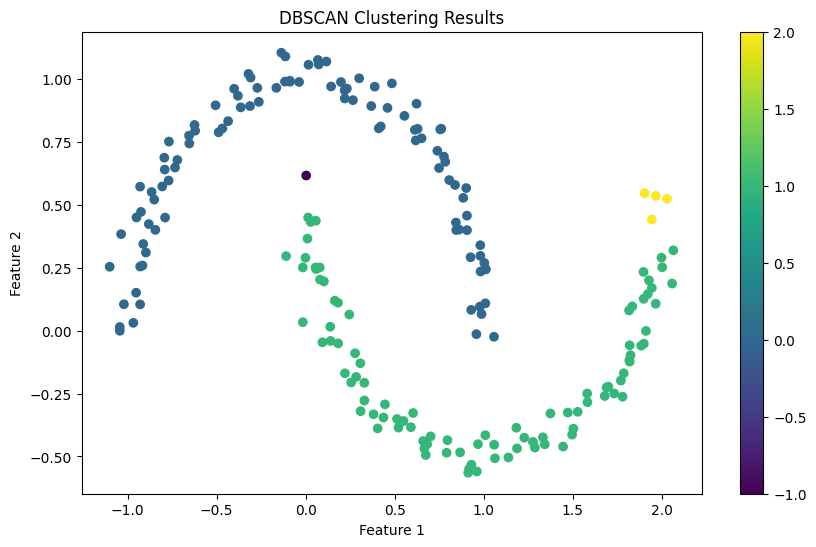

In [10]:
# Visualize the results
plt.figure(figsize = (10 , 6))
scatter = plt.scatter(X[ : , 0], X[ : , 1], c = clusters , cmap = 'viridis')
plt.colorbar(scatter)
plt.title('DBSCAN Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [11]:
# Print number of clusters and noise points
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)
print(f'Number of clusters: {n_clusters}')
print(f'Number of noise points: {n_noise}')

Number of clusters: 3
Number of noise points: 1
